# ЛР 1.3: Пример реальной регрессии

## Теоретическая часть

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


california = fetch_california_housing()
type(california)

sklearn.utils._bunch.Bunch

In [73]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [74]:
print(type(california.data), type(california.target))
print(california.data.shape, california.target.shape)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(20640, 8) (20640,)


## Работа с данными

In [75]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [77]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


## Разделим целевую переменную и факторы

In [78]:
y = data['Price']
X = data.drop('Price', axis=1) # Удаляем столбец, так как axis = 1

y.shape, X.shape

((20640,), (20640, 8))

## Обучим нашу модель

In [79]:
model = LinearRegression()
model.fit(X, y)
print("Coefficients: \n", model.coef_)

Coefficients: 
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]


In [80]:
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)] # Вывод всех факторов и их соответствующих коэффициентов
print("\nСвободный член b0 = ", model.intercept_)

MedInc 0.4366932931343251
HouseAge 0.009435778033238192
AveRooms -0.10732204139090433
AveBedrms 0.6450656935198125
Population -3.976389421212774e-06
AveOccup -0.0037865426549709793
Latitude -0.4213143775271436
Longitude -0.43451375467477693

Свободный член b0 =  -36.94192020718437


## Сделаем предсказания

In [81]:
y_pred = model.predict(X)
print(f"Предсказанные значения: {y_pred[:5]})")
print(f"Реальные значени: \n{y[:5]})")

Предсказанные значения: [4.13164983 3.97660644 3.67657094 3.2415985  2.41358744])
Реальные значени: 
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64)


## График сравнения реальных и предсказанных значений

Коэффициент детерминации R2:  0.606232685199805


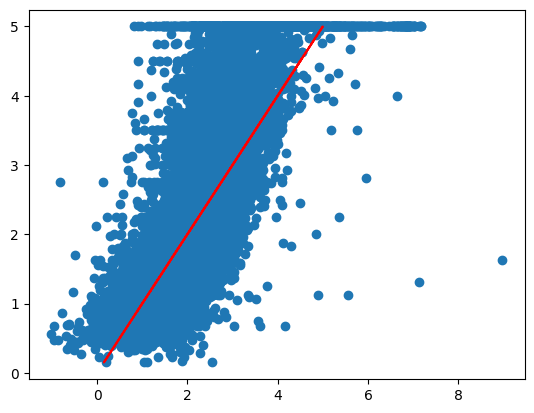

In [82]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

print("Коэффициент детерминации R2: ", model.score(X, y))

## Полиномиальная зависимость с улучшенной точностью

In [83]:
poly = PolynomialFeatures(3).fit_transform(X) # 3-ой степени c 5-ой степенью R2 = 0.3663

polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

## График сравнения реальных и предсказанных значений полиномом 3-ой степени

Коэффициент детерминации R2:  0.7286583856619354


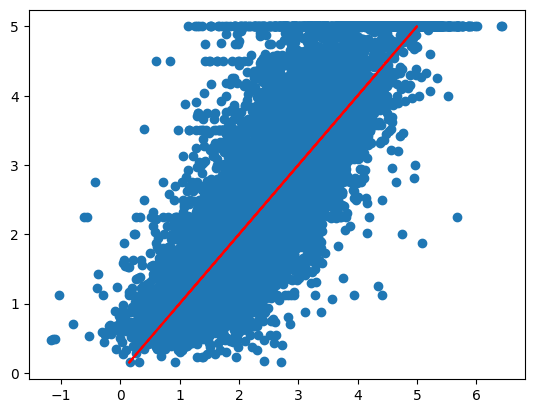

In [84]:
plt.scatter(y_pred_poly, y)
plt.plot(y, y, c='r')


print("Коэффициент детерминации R2: ", polynomial.score(poly, y))

# =======================================================================================

# **Самостоятельные задания**

## 1. Изменение аргументов при создании модели

In [85]:
from sklearn.metrics import r2_score, mean_squared_error

# Изменяем степень полинома, например, с 2 до 5
degree_list = [2, 3, 4, 5]
for degree in degree_list:
    print(f"\nОбучение модели с полиномом степени {degree}")
    poly = PolynomialFeatures(degree=degree).fit_transform(X)
    model = LinearRegression()
    model.fit(poly, y)

    # Предсказываем
    y_pred = model.predict(poly)

    # Выводим R^2
    r2 = r2_score(y, y_pred)
    # Среднеквадратичная ошибка
    mse = mean_squared_error(y, y_pred)
    print(f"R^2 = {r2:.4f}")
    print(f"MSE = {mse:.4f}")

    print(poly.shape)

    # Коэффициенты модели
    print("Коэффициенты:", model.coef_)
    print("Свободный член:", model.intercept_)
    print()
    print("======================================================")

    # Можно вывести первые несколько коэффициентов для анализа
    # Например, вместе с названиями признаков (после преобразования)


Обучение модели с полиномом степени 2
R^2 = 0.6833
MSE = 0.4217
(20640, 45)
Коэффициенты: [ 5.91954123e-08 -1.12430252e+01 -8.48898543e-01  6.44105897e+00
 -3.15913287e+01  4.06090355e-04  1.00386234e+00  8.70568189e+00
  5.88063272e+00 -3.13081271e-02  1.85994684e-03  4.33020466e-02
 -1.86142277e-01  5.72831557e-05 -2.59019510e-03 -1.52505713e-01
 -1.44242939e-01  2.11725336e-04 -1.26219013e-03  1.06115058e-02
  2.81885282e-06 -1.81716946e-03 -1.00690372e-02 -9.99950168e-03
  7.26947729e-03 -6.89064341e-02 -6.82365924e-05  2.68878842e-02
  8.75089875e-02  8.22890338e-02  1.60180950e-01  5.14264268e-04
 -8.71911470e-02 -4.37042992e-01 -4.04150577e-01  2.73779745e-09
  1.91426762e-05  2.29529789e-05  1.46567733e-05  8.71560978e-05
  2.13344592e-02  1.62412938e-02  6.18867358e-02  1.08107173e-01
  3.99077351e-02]
Свободный член: 205.12326361815144


Обучение модели с полиномом степени 3
R^2 = 0.7287
MSE = 0.3613
(20640, 165)
Коэффициенты: [-3.61282784e-10  2.25498864e-06 -6.89037975e-05

## 2. Другие модели регрессии

Линейная регрессия R^2: 0.576


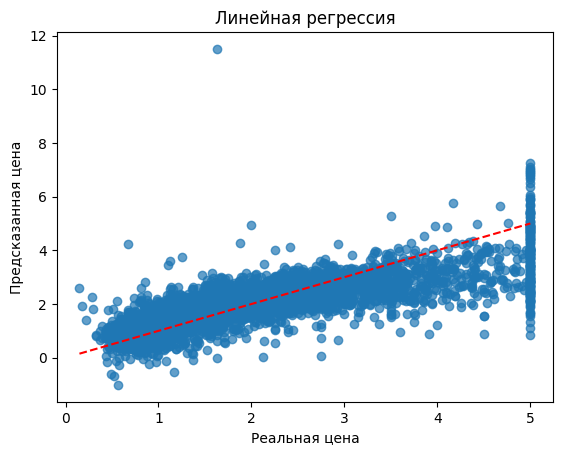

KNeighborsRegressor R^2: 0.670


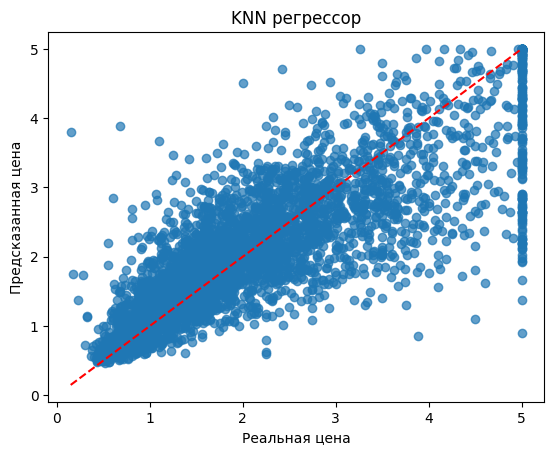

MLPRegressor R^2: 0.777


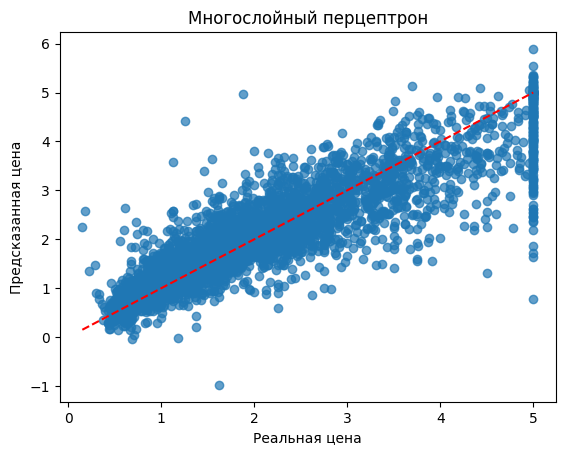

DecisionTreeRegressor R^2: 0.623


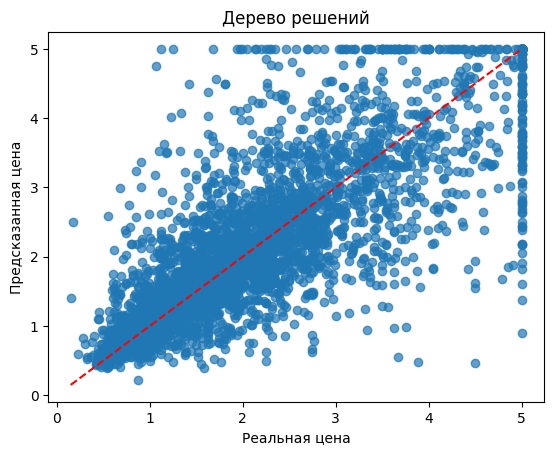

RandomForestRegressor R^2: 0.805


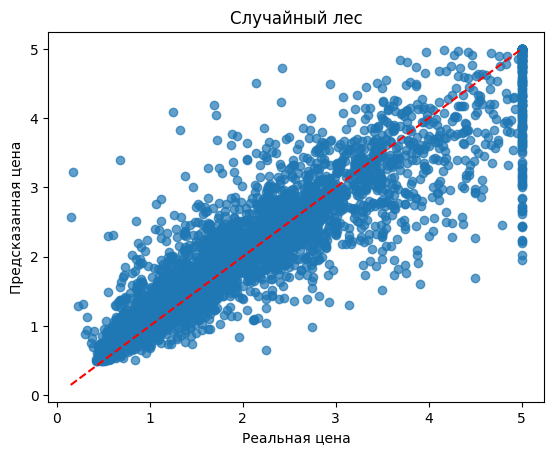

SVR (линейное ядро) R^2: 0.558


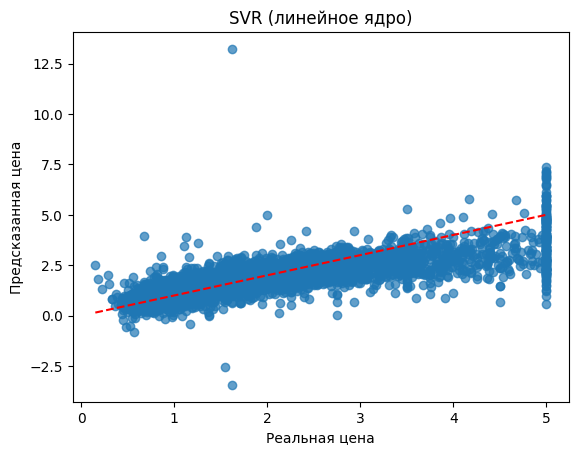

SVR (RBF ядро) R^2: 0.756


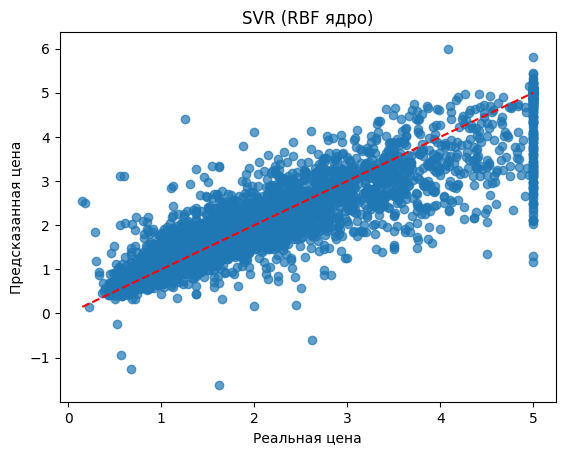

In [86]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Загрузка данных
california = fetch_california_housing()
data = pd.DataFrame(california.data, columns=california.feature_names)
data['Price'] = california.target

X = data.drop('Price', axis=1)
y = data['Price']

# Разделение на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование признаков и целевой переменной
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

# Функция для построения и отображения графика
def plot_predictions(y_true, y_pred, title):
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Реальная цена')
    plt.ylabel('Предсказанная цена')
    plt.title(title)
    plt.show()



# ------------------------------
# 1. Линейная регрессия (LinearRegression)
# ------------------------------
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)

r2_linear = r2_score(y_test, y_pred_lin)
print(f"Линейная регрессия R^2: {r2_linear:.3f}")
plot_predictions(y_test, y_pred_lin, 'Линейная регрессия')



# ------------------------------
# 2. Метод ближайших соседей (KNeighbors)
# ------------------------------
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

r2_knn = r2_score(y_test, y_pred_knn)
print(f"KNeighborsRegressor R^2: {r2_knn:.3f}")
plot_predictions(y_test, y_pred_knn, 'KNN регрессор')



# ------------------------------
# 3. Многослойный перцептрон (MLPRegressor)
# ------------------------------
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

r2_mlp = r2_score(y_test, y_pred_mlp)
print(f"MLPRegressor R^2: {r2_mlp:.3f}")
plot_predictions(y_test, y_pred_mlp, 'Многослойный перцептрон')



# ------------------------------
# 4. Дерево решений (DecisionTreeRegressor)
# ------------------------------
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_scaled, y_train)
y_pred_tree = tree.predict(X_test_scaled)

r2_tree = r2_score(y_test, y_pred_tree)
print(f"DecisionTreeRegressor R^2: {r2_tree:.3f}")
plot_predictions(y_test, y_pred_tree, 'Дерево решений')



# ------------------------------
# 5. Случайный лес (RandomForestRegressor)
# ------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

r2_rf = r2_score(y_test, y_pred_rf)
print(f"RandomForestRegressor R^2: {r2_rf:.3f}")
plot_predictions(y_test, y_pred_rf, 'Случайный лес')



# ------------------------------
# 6. Метод опорных векторов (SVR) с разными ядрами
# ------------------------------
svr_models = [
    ('SVR (линейное ядро)', SVR(kernel='linear', C=100, epsilon=0.1)),
    ('SVR (RBF ядро)', SVR(kernel='rbf', C=100, epsilon=0.1)),
]

for name, model in svr_models:
    model.fit(X_train_scaled, y_train)
    y_pred_svr = model.predict(X_test_scaled)
    r2_svr = r2_score(y_test, y_pred_svr)
    print(f"{name} R^2: {r2_svr:.3f}")
    plot_predictions(y_test, y_pred_svr, name)

## 3. Фунция с автоматическим обучением

In [87]:
def train_all_models(X_train_scaled, y_train, X_test_scaled, y_test):
    results = {}

    # 1. Линейная регрессия
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    y_pred = lr.predict(X_test_scaled)
    results['LinearRegression'] = r2_score(y_test, y_pred)

    # 2. К ближайших соседей
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    results['KNeighborsRegressor'] = r2_score(y_test, y_pred)

    # 3. Многослойный перцептрон
    mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    results['MLPRegressor'] = r2_score(y_test, y_pred)

    # 4. Дерево решений
    tree = DecisionTreeRegressor(random_state=42)
    tree.fit(X_train_scaled, y_train)
    y_pred = tree.predict(X_test_scaled)
    results['DecisionTreeRegressor'] = r2_score(y_test, y_pred)

    # 5. Метод опорных векторов (разные ядра)
    kernels = ['linear', 'rbf']
    for kernel in kernels:
        svr = SVR(kernel=kernel, C=1.0, epsilon=0.1)
        svr.fit(X_train_scaled, y_train)
        y_pred = svr.predict(X_test_scaled)
        key = f'SVR_{kernel}'
        results[key] = r2_score(y_test, y_pred)

    # 6. Случайный лес
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)
    results['RandomForestRegressor'] = r2_score(y_test, y_pred)

    return results


# Вызов функции и вывод результатов
model_results = train_all_models(X_train_scaled, y_train, X_test_scaled, y_test)
for model_name, score in model_results.items():
    print(f"{model_name}: R^2 = {score:.3f}")

LinearRegression: R^2 = 0.576
KNeighborsRegressor: R^2 = 0.670
MLPRegressor: R^2 = 0.777
DecisionTreeRegressor: R^2 = 0.623
SVR_linear: R^2 = 0.558
SVR_rbf: R^2 = 0.728
RandomForestRegressor: R^2 = 0.805


## 4. Повторный анализ с другим датасетом

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


dia = load_diabetes() # Моделирование уровня диабета у разных категорий людей
type(dia)

sklearn.utils._bunch.Bunch

In [89]:
dia.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [90]:
print(type(dia.data), type(dia.target))
print(dia.data.shape, dia.target.shape)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(442, 10) (442,)


### Работа с данными

In [91]:
data = pd.DataFrame(dia.data, columns = dia.feature_names)
tag = dia.target
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [93]:
data.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14


### Разделим целевую переменную и факторы

In [94]:
y = tag
X = data.copy()

y.shape, X.shape

((442,), (442, 10))

### Обучим нашу модель

In [95]:
model = LinearRegression()
model.fit(X, y)
print("Коэффициенты: \n", model.coef_)

Коэффициенты: 
 [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]


In [96]:
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)] # Вывод всех факторов и их соответствующих коэффициентов
print("\nСвободный член b0 = ", model.intercept_)

age -10.009866299810275
sex -239.81564367242356
bmi 519.8459200544609
bp 324.3846455023237
s1 -792.1756385522303
s2 476.73902100525686
s3 101.04326793803331
s4 177.06323767134595
s5 751.2736995571034
s6 67.62669218370483

Свободный член b0 =  152.13348416289597


### Сделаем предсказания

In [97]:
y_pred = model.predict(X)
print(f"Предсказанные значения: {y_pred[:5]})")
print(f"Реальные значени: \n{y[:5]})")

Предсказанные значения: [206.11667725  68.07103297 176.88279035 166.91445843 128.46225834])
Реальные значени: 
[151.  75. 141. 206. 135.])


### График сравнения реальных и предсказанных значений

Коэффициент детерминации R2:  0.5177484222203498


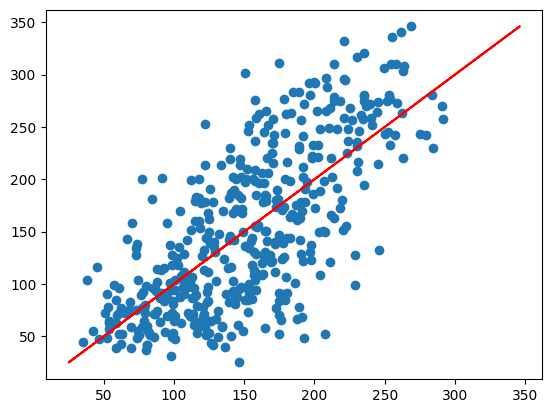

In [98]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

print("Коэффициент детерминации R2: ", model.score(X, y))

### Полиномиальная зависимость с улучшенной точностью

In [99]:
poly = PolynomialFeatures(3).fit_transform(X)

polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

### График сравнения реальных и предсказанных значений полиномом 3-ой степени

Коэффициент детерминации R2:  0.7980671723792674


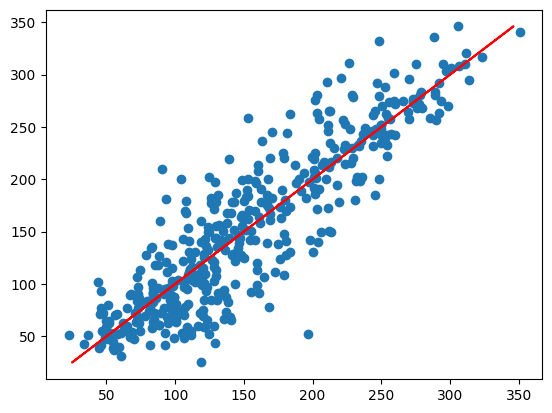

In [100]:
plt.scatter(y_pred_poly, y)
plt.plot(y, y, c='r')


print("Коэффициент детерминации R2: ", polynomial.score(poly, y))